# ExaSPIM Foreground-Background Intensity Analysis

This notebook compares intensity distributions inside and outside the segmentation mask for one ExaSPIM tile across the available OME-Zarr multiscale pyramid levels.

The analysis chooses a physical z window around the strongest mask slice, maps that window to each pyramid level, and computes exact masked and unmasked medians from chunked intensity histograms.

In [13]:
%matplotlib inline

from __future__ import annotations

import gc
import math
import time
import uuid

import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import s3fs
import zarr
from distributed import Client, as_completed, get_client, get_worker

try:
    display
except NameError:
    def display(obj):
        print(obj)


In [14]:
# --- User parameters ---------------------------------------------------------
AWS_REGION = "us-west-2"
IMAGE_ROOT = "s3://aind-open-data/exaSPIM_822178_2026-04-03_19-07-07_processed_2026-04-16_13-16-45/denoised/SPIM.ome.zarr"
MASK_ROOT = "s3://aind-open-data/exaSPIM_822178_2026-04-03_19-07-07_processed_2026-04-16_13-16-45/flatfield_correction/mask/SPIM.ome.zarr"
TILE_NAME = "tile_000015_ch_561.zarr"
REQUESTED_LEVELS = [str(level) for level in range(7)]

# Level-0 z half-width around the selected physical center slice. The notebook
# maps this physical z range to every other pyramid level.
LEVEL0_HALF_WIDTH_Z = 128

# Fallback row block size used only if chunk metadata is unavailable. Larger values reduce
# loop overhead; smaller values reduce peak memory during level 0 processing.
ROW_BLOCK_SIZE = 512

# Distributed execution for per-block histogram tasks. Increase workers or
# pending blocks if the notebook has enough memory and network bandwidth.
DASK_N_WORKERS = 30
DASK_THREADS_PER_WORKER = 1
DASK_PROCESSES = True
DASK_MEMORY_LIMIT = "auto"
DASK_MAX_PENDING_BLOCKS = 1024
DASK_PROGRESS_EVERY = 500
S3_MAX_POOL_CONNECTIONS = 64

# Plot low intensities with unit-width bins. Exact medians are still
# computed from full uint16 bincounts.
LOW_INTENSITY_MAX = 50
LOW_INTENSITY_BIN_WIDTH = 1

# Intensities above LOW_INTENSITY_MAX are retained in the plotted histogram,
# but compressed into coarse tail bins.
TAIL_DISPLAY_BINS = 256
PLOT_X_MAX = LOW_INTENSITY_MAX + 1


In [15]:
def get_or_create_dask_client(
    n_workers: int = DASK_N_WORKERS,
    threads_per_worker: int = DASK_THREADS_PER_WORKER,
    processes: bool = DASK_PROCESSES,
    memory_limit: str = DASK_MEMORY_LIMIT,
) -> Client:
    """Reuse an active distributed Client or start a local one."""
    try:
        client = get_client()
        print(f"Using existing Dask client: {client}")
        return client
    except ValueError:
        pass

    client = Client(
        n_workers=n_workers,
        threads_per_worker=threads_per_worker,
        processes=processes,
        memory_limit=memory_limit,
    )
    print(f"Started Dask client: {client}")
    if client.dashboard_link:
        print(f"Dask dashboard: {client.dashboard_link}")
    return client


DASK_CLIENT = get_or_create_dask_client()


def s3_join(*parts: str) -> str:
    """Join S3 path pieces without losing the s3:// prefix."""
    first, *rest = parts
    return first.rstrip("/") + "/" + "/".join(part.strip("/") for part in rest)


def open_group_from_s3(path: str, s3: s3fs.S3FileSystem) -> zarr.hierarchy.Group:
    store = s3fs.S3Map(root=path.rstrip("/"), s3=s3, check=False)
    return zarr.open_group(store=store, mode="r")


def sorted_numeric_array_keys(group: zarr.hierarchy.Group) -> list[str]:
    return sorted([key for key in group.array_keys() if key.isdigit()], key=int)


def squeeze_to_zyx(array: da.Array | zarr.core.Array) -> da.Array:
    """Convert a singleton TCZYX array to a Dask ZYX array."""
    squeezed = da.from_zarr(array).squeeze()
    if squeezed.ndim != 3:
        raise ValueError(f"Expected singleton TCZYX data after squeeze, got {squeezed.shape}")
    return squeezed


def level_metadata_row(
    level: str,
    image_group: zarr.hierarchy.Group,
    mask_group: zarr.hierarchy.Group,
) -> dict:
    image_present = level in image_group
    mask_present = level in mask_group
    row = {
        "level": level,
        "image_present": image_present,
        "mask_present": mask_present,
        "usable": image_present and mask_present,
    }
    if image_present:
        arr = image_group[level]
        row.update(
            image_shape=arr.shape,
            image_chunks=arr.chunks,
            image_dtype=str(arr.dtype),
        )
    else:
        row.update(image_shape=None, image_chunks=None, image_dtype=None)
    if mask_present:
        arr = mask_group[level]
        row.update(
            mask_shape=arr.shape,
            mask_chunks=arr.chunks,
            mask_dtype=str(arr.dtype),
        )
    else:
        row.update(mask_shape=None, mask_chunks=None, mask_dtype=None)
    return row


Using existing Dask client: <Client: 'tcp://127.0.0.1:39993' processes=30 threads=30, memory=230.97 GiB>


In [16]:
# Open the tile-level image and mask OME-Zarr groups.
s3 = s3fs.S3FileSystem(anon=True, client_kwargs={"region_name": AWS_REGION})

image_tile_path = s3_join(IMAGE_ROOT, TILE_NAME)
mask_tile_path = s3_join(MASK_ROOT, TILE_NAME)

image_group = open_group_from_s3(image_tile_path, s3)
mask_group = open_group_from_s3(mask_tile_path, s3)

metadata_df = pd.DataFrame(
    level_metadata_row(level, image_group, mask_group)
    for level in REQUESTED_LEVELS
)

display(metadata_df)

analyzed_levels = metadata_df.loc[metadata_df["usable"], "level"].tolist()
missing_levels = metadata_df.loc[~metadata_df["usable"], "level"].tolist()

print(f"Analyzing levels present in both image and mask: {analyzed_levels}")
if missing_levels:
    print(f"Skipping requested levels that are absent from image or mask: {missing_levels}")

if not analyzed_levels:
    raise RuntimeError("No requested pyramid levels are present in both image and mask groups.")


,level,image_present,mask_present,usable,image_shape,image_chunks,image_dtype,mask_shape,mask_chunks,mask_dtype
0,0,True,True,True,"(1, 1, 18432, 10640, 14192)","(1, 1, 128, 256, 256)",uint16,"(1, 1, 18432, 10640, 14192)","(1, 1, 128, 256, 256)",uint8
1,1,True,True,True,"(1, 1, 9216, 5320, 7096)","(1, 1, 128, 256, 256)",uint16,"(1, 1, 9216, 5320, 7096)","(1, 1, 128, 256, 256)",uint8
2,2,True,True,True,"(1, 1, 4608, 2660, 3548)","(1, 1, 128, 256, 256)",uint16,"(1, 1, 4608, 2660, 3548)","(1, 1, 128, 256, 256)",uint8
3,3,True,True,True,"(1, 1, 2304, 1330, 1774)","(1, 1, 128, 256, 256)",uint16,"(1, 1, 2304, 1330, 1774)","(1, 1, 128, 256, 256)",uint8
4,4,True,True,True,"(1, 1, 1152, 665, 887)","(1, 1, 128, 256, 256)",uint16,"(1, 1, 1152, 665, 887)","(1, 1, 128, 256, 256)",uint8
5,5,True,True,True,"(1, 1, 576, 332, 443)","(1, 1, 128, 256, 256)",uint16,"(1, 1, 576, 332, 443)","(1, 1, 128, 256, 256)",uint8
6,6,True,True,True,"(1, 1, 288, 166, 221)","(1, 1, 128, 166, 221)",uint16,"(1, 1, 288, 166, 221)","(1, 1, 128, 166, 221)",uint8


Analyzing levels present in both image and mask: ['0', '1', '2', '3', '4', '5', '6']


In [17]:
def _axis_index(group: zarr.hierarchy.Group, axis_name: str) -> int:
    attrs = group.attrs.asdict()
    multiscales = attrs.get("multiscales", [])
    if multiscales:
        axes = multiscales[0].get("axes", [])
        for idx, axis in enumerate(axes):
            if axis.get("name") == axis_name:
                return idx
    # OME-Zarr arrays in this dataset are TCZYX.
    defaults = {"t": 0, "c": 1, "z": 2, "y": 3, "x": 4}
    return defaults[axis_name]


def _dataset_transform(group: zarr.hierarchy.Group, level: str) -> tuple[list[float], list[float]]:
    attrs = group.attrs.asdict()
    for multiscale in attrs.get("multiscales", []):
        for dataset in multiscale.get("datasets", []):
            if str(dataset.get("path")) != str(level):
                continue
            scale = None
            translation = None
            for transform in dataset.get("coordinateTransformations", []):
                if transform.get("type") == "scale":
                    scale = transform.get("scale")
                elif transform.get("type") == "translation":
                    translation = transform.get("translation")
            if scale is None:
                raise KeyError(f"No scale transform found for level {level}")
            if translation is None:
                translation = [0.0] * len(scale)
            return [float(v) for v in scale], [float(v) for v in translation]
    raise KeyError(f"No multiscale dataset metadata found for level {level}")


def z_center_physical(group: zarr.hierarchy.Group, level: str, z_index: int) -> float:
    z_axis = _axis_index(group, "z")
    scale, translation = _dataset_transform(group, level)
    return translation[z_axis] + (z_index + 0.5) * scale[z_axis]


def z_index_from_physical(
    group: zarr.hierarchy.Group,
    level: str,
    physical_z: float,
    z_size: int,
) -> int:
    z_axis = _axis_index(group, "z")
    scale, translation = _dataset_transform(group, level)
    z_float = (physical_z - translation[z_axis]) / scale[z_axis] - 0.5
    return int(np.clip(round(z_float), 0, z_size - 1))


def z_index_from_shape_ratio(
    reference_z: int,
    reference_shape: tuple[int, int, int],
    target_shape: tuple[int, int, int],
) -> int:
    z_float = (reference_z + 0.5) * target_shape[0] / reference_shape[0] - 0.5
    return int(np.clip(round(z_float), 0, target_shape[0] - 1))


def z_boundaries_physical(
    group: zarr.hierarchy.Group,
    level: str,
    z_start: int,
    z_stop: int,
) -> tuple[float, float]:
    """Return physical lower/upper z boundaries for a half-open index range."""
    z_axis = _axis_index(group, "z")
    scale, translation = _dataset_transform(group, level)
    return (
        translation[z_axis] + z_start * scale[z_axis],
        translation[z_axis] + z_stop * scale[z_axis],
    )


def z_range_from_physical_bounds(
    group: zarr.hierarchy.Group,
    level: str,
    physical_start: float,
    physical_stop: float,
    z_size: int,
) -> tuple[int, int]:
    """Map physical z boundaries to a clamped half-open index range."""
    z_axis = _axis_index(group, "z")
    scale, translation = _dataset_transform(group, level)
    start_float = (physical_start - translation[z_axis]) / scale[z_axis]
    stop_float = (physical_stop - translation[z_axis]) / scale[z_axis]
    z_start = int(np.clip(math.floor(start_float), 0, z_size))
    z_stop = int(np.clip(math.ceil(stop_float), 0, z_size))
    if z_stop <= z_start:
        center = z_index_from_physical(
            group, level, (physical_start + physical_stop) / 2, z_size
        )
        z_start = center
        z_stop = min(center + 1, z_size)
    return z_start, z_stop


def z_range_from_shape_ratio(
    reference_start: int,
    reference_stop: int,
    reference_shape: tuple[int, int, int],
    target_shape: tuple[int, int, int],
) -> tuple[int, int]:
    """Fallback half-open range mapping by z-shape ratio."""
    scale = target_shape[0] / reference_shape[0]
    z_start = int(np.clip(math.floor(reference_start * scale), 0, target_shape[0]))
    z_stop = int(np.clip(math.ceil(reference_stop * scale), 0, target_shape[0]))
    if z_stop <= z_start:
        z_start = int(np.clip(z_start, 0, target_shape[0] - 1))
        z_stop = min(z_start + 1, target_shape[0])
    return z_start, z_stop


In [18]:
# Select one physical z center from the coarsest available mask level,
# then build a +/- LEVEL0_HALF_WIDTH_Z range around that center at level 0.
coarsest_level = max(analyzed_levels, key=int)
coarsest_mask = squeeze_to_zyx(mask_group[coarsest_level])

positive_counts_by_z = (coarsest_mask > 0).sum(axis=(1, 2)).compute()
reference_z = int(np.argmax(positive_counts_by_z))
reference_positive_count = int(positive_counts_by_z[reference_z])
reference_shape = tuple(int(v) for v in coarsest_mask.shape)

try:
    reference_physical_z = z_center_physical(mask_group, coarsest_level, reference_z)
    mapping_method = "OME-Zarr physical z metadata"
except Exception as exc:
    reference_physical_z = math.nan
    mapping_method = f"shape-ratio fallback ({type(exc).__name__}: {exc})"

level0 = min(analyzed_levels, key=int)
level0_mask = squeeze_to_zyx(mask_group[level0])
level0_shape = tuple(int(v) for v in level0_mask.shape)

try:
    level0_center_z = z_index_from_physical(
        mask_group, level0, reference_physical_z, level0_shape[0]
    )
except Exception:
    level0_center_z = z_index_from_shape_ratio(reference_z, reference_shape, level0_shape)

level0_z_start = max(0, level0_center_z - LEVEL0_HALF_WIDTH_Z)
level0_z_stop = min(level0_shape[0], level0_center_z + LEVEL0_HALF_WIDTH_Z + 1)

try:
    physical_z_start, physical_z_stop = z_boundaries_physical(
        mask_group, level0, level0_z_start, level0_z_stop
    )
    range_mapping_method = "OME-Zarr physical z metadata"
except Exception as exc:
    physical_z_start = math.nan
    physical_z_stop = math.nan
    range_mapping_method = f"shape-ratio fallback ({type(exc).__name__}: {exc})"

print(
    f"Selected reference center from level {coarsest_level}, z={reference_z}, "
    f"positive mask pixels={reference_positive_count:,}."
)
print(
    f"Level {level0} center z={level0_center_z}; using z range "
    f"[{level0_z_start}, {level0_z_stop}) "
    f"({level0_z_stop - level0_z_start} slices)."
)
print(f"Mapping z ranges with {range_mapping_method}.")

selected_ranges = []
for level in analyzed_levels:
    mask_zyx = squeeze_to_zyx(mask_group[level])
    mask_shape = tuple(int(v) for v in mask_zyx.shape)
    try:
        z_start, z_stop = z_range_from_physical_bounds(
            mask_group, level, physical_z_start, physical_z_stop, mask_shape[0]
        )
        z_center = z_index_from_physical(mask_group, level, reference_physical_z, mask_shape[0])
        method = "physical"
    except Exception:
        z_start, z_stop = z_range_from_shape_ratio(
            level0_z_start, level0_z_stop, level0_shape, mask_shape
        )
        z_center = z_index_from_shape_ratio(level0_center_z, level0_shape, mask_shape)
        method = "shape_ratio"
    selected_ranges.append(
        {
            "level": level,
            "selected_z_center": z_center,
            "z_start": z_start,
            "z_stop": z_stop,
            "z_count": z_stop - z_start,
            "mask_shape_zyx": mask_shape,
            "mapping_method": method,
        }
    )

selected_ranges_df = pd.DataFrame(selected_ranges)
display(selected_ranges_df)


Selected reference center from level 6, z=160, positive mask pixels=10,746.
Level 0 center z=10303; using z range [10175, 10432) (257 slices).
Mapping z ranges with OME-Zarr physical z metadata.


,level,selected_z_center,z_start,z_stop,z_count,mask_shape_zyx,mapping_method
0,0,10303,10175,10432,257,"(18432, 10640, 14192)",physical
1,1,5151,5087,5216,129,"(9216, 5320, 7096)",physical
2,2,2575,2543,2608,65,"(4608, 2660, 3548)",physical
3,3,1287,1271,1304,33,"(2304, 1330, 1774)",physical
4,4,643,635,652,17,"(1152, 665, 887)",physical
5,5,321,317,326,9,"(576, 332, 443)",physical
6,6,160,158,163,5,"(288, 166, 221)",physical


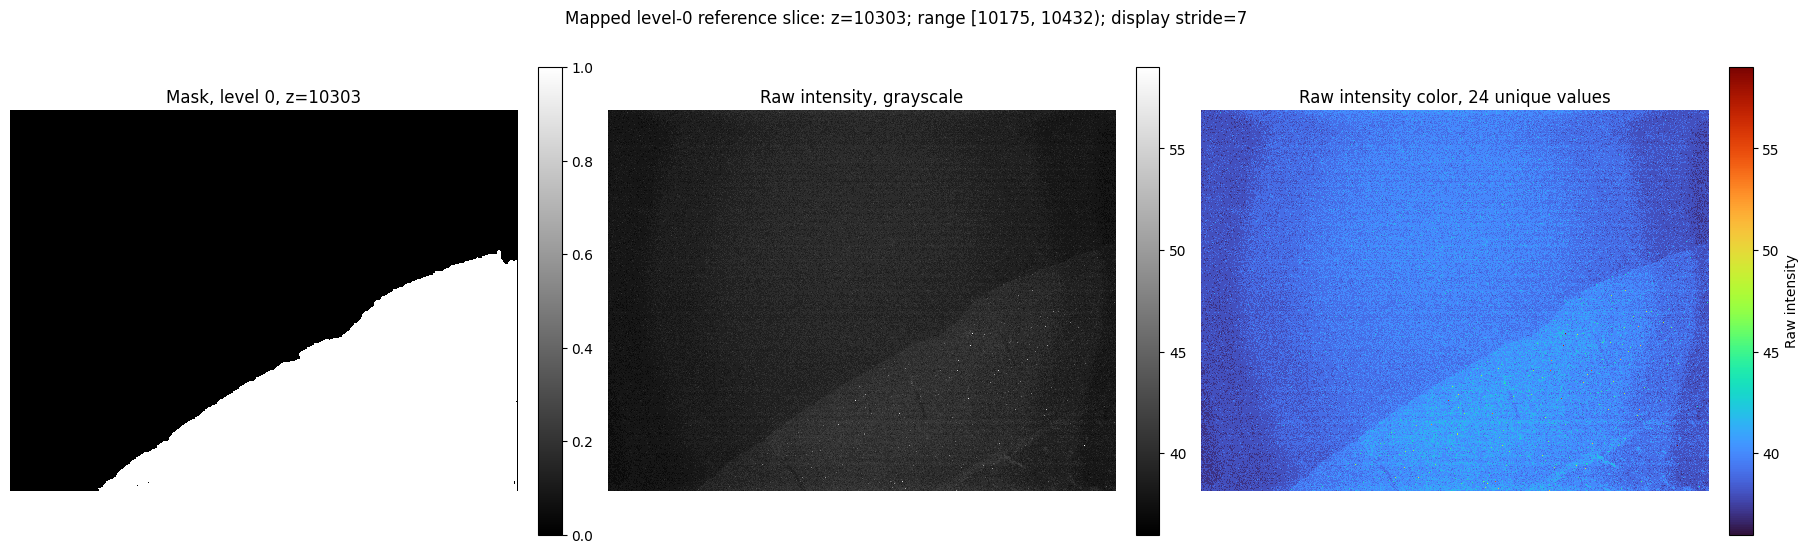

In [19]:
# Visualize the mapped level-0 reference slice used to build the z range.
plot_level = level0
plot_z = level0_center_z
plot_image = squeeze_to_zyx(image_group[plot_level])
plot_mask = squeeze_to_zyx(mask_group[plot_level])

reference_mask_slice = (plot_mask[plot_z].compute() > 0)
reference_image_slice = plot_image[plot_z].compute()

# Count unique uint16 intensities without materializing a large inverse-label image.
intensity_counts = np.bincount(
    reference_image_slice.ravel(),
    minlength=int(np.iinfo(reference_image_slice.dtype).max) + 1,
)
unique_values = np.flatnonzero(intensity_counts)

# Matplotlib does not need every level-0 pixel to display a useful diagnostic.
# Keep the source data at level 0, but stride the rendered preview when needed.
reference_plot_max_pixels = 4_000_000
display_stride = max(
    1,
    int(math.ceil(math.sqrt(reference_image_slice.size / reference_plot_max_pixels))),
)
reference_mask_display = reference_mask_slice[::display_stride, ::display_stride]
reference_image_display = reference_image_slice[::display_stride, ::display_stride]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

mask_im = axes[0].imshow(reference_mask_display, cmap="gray", interpolation="nearest")
axes[0].set_title(f"Mask, level {plot_level}, z={plot_z}")
axes[0].axis("off")
fig.colorbar(mask_im, ax=axes[0], fraction=0.046, pad=0.04)

raw_im = axes[1].imshow(reference_image_display, cmap="gray", interpolation="nearest")
axes[1].set_title("Raw intensity, grayscale")
axes[1].axis("off")
fig.colorbar(raw_im, ax=axes[1], fraction=0.046, pad=0.04)

unique_im = axes[2].imshow(reference_image_display, cmap="turbo", interpolation="nearest")
axes[2].set_title(f"Raw intensity color, {len(unique_values):,} unique values")
axes[2].axis("off")
unique_cbar = fig.colorbar(unique_im, ax=axes[2], fraction=0.046, pad=0.04)
unique_cbar.set_label("Raw intensity")

fig.suptitle(
    f"Mapped level-0 reference slice: z={plot_z}; range [{level0_z_start}, {level0_z_stop}); "
    f"display stride={display_stride}",
    y=1.03,
)
plt.show()


In [20]:
def histogram_length(dtype: np.dtype) -> int:
    dtype = np.dtype(dtype)
    if not np.issubdtype(dtype, np.integer):
        raise TypeError(f"Expected integer intensity data, got {dtype}")
    info = np.iinfo(dtype)
    if info.min < 0:
        raise ValueError(f"Expected unsigned intensity data, got {dtype}")
    return int(info.max) + 1


def median_from_counts(counts: np.ndarray) -> float:
    total = int(counts.sum())
    if total == 0:
        return math.nan
    lower_rank = (total - 1) // 2
    upper_rank = total // 2
    cdf = np.cumsum(counts)
    lower_value = int(np.searchsorted(cdf, lower_rank + 1))
    upper_value = int(np.searchsorted(cdf, upper_rank + 1))
    return (lower_value + upper_value) / 2.0


def clipped_chunk_ranges(
    chunks: tuple[int, ...],
    start: int,
    stop: int,
) -> list[tuple[int, int]]:
    """Return chunk-aligned half-open ranges clipped to [start, stop)."""
    ranges = []
    chunk_start = 0
    for chunk_size in chunks:
        chunk_stop = chunk_start + int(chunk_size)
        block_start = max(start, chunk_start)
        block_stop = min(stop, chunk_stop)
        if block_start < block_stop:
            ranges.append((block_start, block_stop))
        chunk_start = chunk_stop
    return ranges


_LOCAL_ZARR_ARRAY_CACHE = {}


def worker_cache_dict() -> dict:
    """Return a worker-local cache, with a local fallback for non-distributed tests."""
    try:
        worker = get_worker()
    except ValueError:
        return _LOCAL_ZARR_ARRAY_CACHE

    cache = getattr(worker, "_mask_intensity_zarr_cache", None)
    if cache is None:
        cache = {}
        setattr(worker, "_mask_intensity_zarr_cache", cache)
    return cache


def worker_zarr_array(
    tile_path: str,
    level: str,
    aws_region: str,
    s3_max_pool_connections: int,
) -> zarr.core.Array:
    """Open and cache one tile-level Zarr array inside the worker process."""
    cache = worker_cache_dict()
    key = (tile_path.rstrip("/"), str(level), aws_region, int(s3_max_pool_connections))
    if key not in cache:
        s3 = s3fs.S3FileSystem(
            anon=True,
            client_kwargs={"region_name": aws_region},
            config_kwargs={"max_pool_connections": int(s3_max_pool_connections)},
        )
        store = s3fs.S3Map(root=tile_path.rstrip("/"), s3=s3, check=False)
        group = zarr.open_group(store=store, mode="r")
        cache[key] = group[str(level)]
    return cache[key]


def read_zyx_block(
    array: zarr.core.Array,
    block: tuple[int, int, int, int, int, int],
) -> np.ndarray:
    """Read one ZYX block from a 3D array or singleton TCZYX array."""
    z0, z1, y0, y1, x0, x1 = block
    if array.ndim == 5:
        return np.asarray(array[0, 0, z0:z1, y0:y1, x0:x1])
    if array.ndim == 3:
        return np.asarray(array[z0:z1, y0:y1, x0:x1])
    raise ValueError(f"Expected 3D or singleton TCZYX array, got shape {array.shape}")


def block_histogram_counts(
    image_block: np.ndarray,
    mask_block: np.ndarray,
    hist_len: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute inside/outside bincounts for one concrete image block."""
    mask_block = mask_block.astype(bool, copy=False)
    inside_counts = np.bincount(
        image_block[mask_block].ravel(), minlength=hist_len
    ).astype(np.int64, copy=False)
    outside_counts = np.bincount(
        image_block[~mask_block].ravel(), minlength=hist_len
    ).astype(np.int64, copy=False)
    return inside_counts, outside_counts


def worker_block_histogram(
    image_tile_path: str,
    mask_tile_path: str,
    level: str,
    block: tuple[int, int, int, int, int, int],
    hist_len: int,
    aws_region: str,
    s3_max_pool_connections: int,
) -> tuple[np.ndarray, np.ndarray, dict]:
    """Open/read one image+mask block on the worker and return histograms."""
    total_start = time.perf_counter()
    read_start = time.perf_counter()
    image_array = worker_zarr_array(
        image_tile_path, level, aws_region, s3_max_pool_connections
    )
    mask_array = worker_zarr_array(
        mask_tile_path, level, aws_region, s3_max_pool_connections
    )
    image_block = read_zyx_block(image_array, block)
    mask_block = read_zyx_block(mask_array, block) > 0
    read_seconds = time.perf_counter() - read_start

    histogram_start = time.perf_counter()
    inside_counts, outside_counts = block_histogram_counts(
        image_block, mask_block, hist_len
    )
    histogram_seconds = time.perf_counter() - histogram_start
    total_seconds = time.perf_counter() - total_start

    z0, z1, y0, y1, x0, x1 = block
    timing = {
        "level": str(level),
        "z0": z0,
        "z1": z1,
        "y0": y0,
        "y1": y1,
        "x0": x0,
        "x1": x1,
        "read_seconds": read_seconds,
        "histogram_seconds": histogram_seconds,
        "total_seconds": total_seconds,
        "image_bytes": int(image_block.nbytes),
        "mask_bytes": int(mask_block.nbytes),
        "inside_pixel_count": int(inside_counts.sum()),
        "outside_pixel_count": int(outside_counts.sum()),
    }
    return inside_counts, outside_counts, timing


def submit_block_histogram(
    client: Client,
    image_tile_path: str,
    mask_tile_path: str,
    level: str,
    block: tuple[int, int, int, int, int, int],
    hist_len: int,
    aws_region: str = AWS_REGION,
    s3_max_pool_connections: int = S3_MAX_POOL_CONNECTIONS,
):
    """Submit one self-contained worker-side read plus histogram task."""
    z0, z1, y0, y1, x0, x1 = block
    key = f"block-hist-{level}-{z0}-{z1}-{y0}-{y1}-{x0}-{x1}-{uuid.uuid4().hex}"
    return client.submit(
        worker_block_histogram,
        image_tile_path,
        mask_tile_path,
        str(level),
        block,
        hist_len,
        aws_region,
        s3_max_pool_connections,
        key=key,
        pure=False,
    )


def z_range_histograms(
    level: str,
    image_zyx: da.Array,
    mask_zyx: da.Array,
    z_start: int,
    z_stop: int,
    row_block_size: int = ROW_BLOCK_SIZE,
    client: Client | None = None,
    max_pending_blocks: int = DASK_MAX_PENDING_BLOCKS,
    progress_every: int = DASK_PROGRESS_EVERY,
    image_tile_path_for_workers: str | None = None,
    mask_tile_path_for_workers: str | None = None,
    aws_region: str = AWS_REGION,
    s3_max_pool_connections: int = S3_MAX_POOL_CONNECTIONS,
) -> dict:
    """Compute exact inside/outside histograms for one selected z range."""
    if image_zyx.shape != mask_zyx.shape:
        raise ValueError(f"Image and mask shapes differ: {image_zyx.shape} != {mask_zyx.shape}")
    if not (0 <= z_start < z_stop <= image_zyx.shape[0]):
        raise ValueError(f"Invalid z range [{z_start}, {z_stop}) for shape {image_zyx.shape}")

    hist_len = histogram_length(image_zyx.dtype)
    inside_counts = np.zeros(hist_len, dtype=np.int64)
    outside_counts = np.zeros(hist_len, dtype=np.int64)

    _, y_size, x_size = image_zyx.shape
    z_ranges = clipped_chunk_ranges(image_zyx.chunks[0], z_start, z_stop)
    y_ranges = clipped_chunk_ranges(image_zyx.chunks[1], 0, y_size)
    x_ranges = clipped_chunk_ranges(image_zyx.chunks[2], 0, x_size)

    # Fall back to row blocks if a non-standard array has missing chunk metadata.
    if not y_ranges:
        y_ranges = [(y0, min(y0 + row_block_size, y_size)) for y0 in range(0, y_size, row_block_size)]
    if not x_ranges:
        x_ranges = [(0, x_size)]

    blocks = [
        (z0, z1, y0, y1, x0, x1)
        for z0, z1 in z_ranges
        for y0, y1 in y_ranges
        for x0, x1 in x_ranges
    ]
    total_blocks = len(blocks)
    if total_blocks == 0:
        raise RuntimeError(f"No blocks generated for z range [{z_start}, {z_stop})")

    client = client or DASK_CLIENT
    image_tile_path_for_workers = image_tile_path_for_workers or image_tile_path
    mask_tile_path_for_workers = mask_tile_path_for_workers or mask_tile_path
    max_pending = max(1, min(int(max_pending_blocks), total_blocks))
    progress_every = max(1, int(progress_every))
    print(
        f"  Submitting {total_blocks:,} chunk-aligned histogram blocks "
        f"for z [{z_start}, {z_stop}); max {max_pending:,} futures in flight"
    )

    wall_start = time.perf_counter()
    block_iter = iter(blocks)
    completed = 0
    submitted = 0
    block_timings = []
    completed_futures = as_completed()

    def submit_next_block():
        block = next(block_iter)
        return submit_block_histogram(
            client,
            image_tile_path_for_workers,
            mask_tile_path_for_workers,
            level,
            block,
            hist_len,
            aws_region=aws_region,
            s3_max_pool_connections=s3_max_pool_connections,
        )

    while submitted < max_pending:
        completed_futures.add(submit_next_block())
        submitted += 1

    for future in completed_futures:
        try:
            inside_block_counts, outside_block_counts, block_timing = future.result()
            inside_counts += inside_block_counts
            outside_counts += outside_block_counts
            block_timings.append(block_timing)
        finally:
            future.release()

        completed += 1
        if completed % progress_every == 0 or completed == total_blocks:
            print(f"    Completed {completed:,}/{total_blocks:,} blocks")

        if submitted < total_blocks:
            completed_futures.add(submit_next_block())
            submitted += 1

        if completed >= total_blocks:
            break

    gc.collect()
    wall_seconds = time.perf_counter() - wall_start
    block_timings_df = pd.DataFrame(block_timings)
    if not block_timings_df.empty:
        read_seconds_total = float(block_timings_df["read_seconds"].sum())
        histogram_seconds_total = float(block_timings_df["histogram_seconds"].sum())
        total_block_seconds = float(block_timings_df["total_seconds"].sum())
        mean_block_read_seconds = float(block_timings_df["read_seconds"].mean())
        mean_block_histogram_seconds = float(block_timings_df["histogram_seconds"].mean())
        max_block_read_seconds = float(block_timings_df["read_seconds"].max())
        max_block_histogram_seconds = float(block_timings_df["histogram_seconds"].max())
    else:
        read_seconds_total = 0.0
        histogram_seconds_total = 0.0
        total_block_seconds = 0.0
        mean_block_read_seconds = math.nan
        mean_block_histogram_seconds = math.nan
        max_block_read_seconds = math.nan
        max_block_histogram_seconds = math.nan
    print(
        f"  Level {level} wall time: {wall_seconds:.1f}s; "
        f"summed block read time: {read_seconds_total:.1f}s; "
        f"summed block histogram time: {histogram_seconds_total:.1f}s"
    )

    return {
        "inside_counts": inside_counts,
        "outside_counts": outside_counts,
        "inside_pixel_count": int(inside_counts.sum()),
        "outside_pixel_count": int(outside_counts.sum()),
        "inside_median_intensity": median_from_counts(inside_counts),
        "outside_median_intensity": median_from_counts(outside_counts),
        "volume_shape_zyx": (int(z_stop - z_start), int(y_size), int(x_size)),
        "z_start": int(z_start),
        "z_stop": int(z_stop),
        "z_count": int(z_stop - z_start),
        "block_count": int(total_blocks),
        "wall_seconds": wall_seconds,
        "total_block_seconds": total_block_seconds,
        "total_block_read_seconds": read_seconds_total,
        "total_block_histogram_seconds": histogram_seconds_total,
        "mean_block_read_seconds": mean_block_read_seconds,
        "mean_block_histogram_seconds": mean_block_histogram_seconds,
        "max_block_read_seconds": max_block_read_seconds,
        "max_block_histogram_seconds": max_block_histogram_seconds,
        "block_timings": block_timings_df,
    }


def compute_level_result(level: str, z_start: int, z_stop: int) -> dict:
    image_zyx = squeeze_to_zyx(image_group[level])
    mask_zyx = squeeze_to_zyx(mask_group[level])
    result = z_range_histograms(
        level,
        image_zyx,
        mask_zyx,
        z_start,
        z_stop,
        image_tile_path_for_workers=image_tile_path,
        mask_tile_path_for_workers=mask_tile_path,
    )
    result.update(level=level)
    return result


In [21]:
# Smoke-test the smallest selected z range first.
results_by_level: dict[str, dict] = {}
smoke_level = coarsest_level
smoke_row = selected_ranges_df.loc[selected_ranges_df["level"] == smoke_level].iloc[0]
smoke_z_start = int(smoke_row["z_start"])
smoke_z_stop = int(smoke_row["z_stop"])

print(f"Smoke-testing level {smoke_level} over z [{smoke_z_start}, {smoke_z_stop})...")
results_by_level[smoke_level] = compute_level_result(
    smoke_level, smoke_z_start, smoke_z_stop
)

display(
    pd.DataFrame(
        [
            {
                key: value
                for key, value in results_by_level[smoke_level].items()
                if not key.endswith("_counts") and key != "block_timings"
            }
        ]
    )
)


Smoke-testing level 6 over z [158, 163)...
  Submitting 1 chunk-aligned histogram blocks for z [158, 163); max 1 futures in flight
    Completed 1/1 blocks
  Level 6 wall time: 0.9s; summed block read time: 0.3s; summed block histogram time: 0.0s


,inside_pixel_count,outside_pixel_count,inside_median_intensity,outside_median_intensity,volume_shape_zyx,z_start,z_stop,z_count,block_count,wall_seconds,total_block_seconds,total_block_read_seconds,total_block_histogram_seconds,mean_block_read_seconds,mean_block_histogram_seconds,max_block_read_seconds,max_block_histogram_seconds,level
0,53440,129990,42.0,41.0,"(5, 166, 221)",158,163,5,1,0.918737,0.346107,0.345065,0.001041,0.345065,0.001041,0.345065,0.001041,6


In [22]:
# Compute exact histograms and medians for every available level.
for row in selected_ranges_df.itertuples(index=False):
    if row.level in results_by_level:
        continue
    print(f"Computing level {row.level} over z [{row.z_start}, {row.z_stop})...")
    results_by_level[row.level] = compute_level_result(row.level, row.z_start, row.z_stop)

summary_rows = []
for level in analyzed_levels:
    result = results_by_level[level]
    summary_rows.append(
        {
            "level": level,
            "z_start": result["z_start"],
            "z_stop": result["z_stop"],
            "z_count": result["z_count"],
            "volume_shape_zyx": result["volume_shape_zyx"],
            "block_count": result["block_count"],
            "wall_seconds": result["wall_seconds"],
            "total_block_read_seconds": result["total_block_read_seconds"],
            "total_block_histogram_seconds": result["total_block_histogram_seconds"],
            "mean_block_read_seconds": result["mean_block_read_seconds"],
            "mean_block_histogram_seconds": result["mean_block_histogram_seconds"],
            "inside_pixel_count": result["inside_pixel_count"],
            "outside_pixel_count": result["outside_pixel_count"],
            "inside_median_intensity": result["inside_median_intensity"],
            "outside_median_intensity": result["outside_median_intensity"],
        }
    )

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


Computing level 0 over z [10175, 10432)...
  Submitting 7,056 chunk-aligned histogram blocks for z [10175, 10432); max 1,024 futures in flight
    Completed 500/7,056 blocks
    Completed 1,000/7,056 blocks
    Completed 1,500/7,056 blocks
    Completed 2,000/7,056 blocks
    Completed 2,500/7,056 blocks
    Completed 3,000/7,056 blocks
    Completed 3,500/7,056 blocks
    Completed 4,000/7,056 blocks
    Completed 4,500/7,056 blocks
    Completed 5,000/7,056 blocks
    Completed 5,500/7,056 blocks
    Completed 6,000/7,056 blocks
    Completed 6,500/7,056 blocks
    Completed 7,000/7,056 blocks
    Completed 7,056/7,056 blocks
  Level 0 wall time: 78.4s; summed block read time: 1107.7s; summed block histogram time: 171.7s
Computing level 1 over z [5087, 5216)...
  Submitting 1,176 chunk-aligned histogram blocks for z [5087, 5216); max 1,024 futures in flight
    Completed 500/1,176 blocks
    Completed 1,000/1,176 blocks
    Completed 1,176/1,176 blocks
  Level 1 wall time: 12.7s; sum

,level,z_start,z_stop,z_count,volume_shape_zyx,block_count,wall_seconds,total_block_read_seconds,total_block_histogram_seconds,mean_block_read_seconds,mean_block_histogram_seconds,inside_pixel_count,outside_pixel_count,inside_median_intensity,outside_median_intensity
0,0,10175,10432,257,"(257, 10640, 14192)",7056,78.401450,1107.706069,171.711874,0.156988,0.024336,11613012672,27194727488,40.0,39.0
1,1,5087,5216,129,"(129, 5320, 7096)",1176,12.729212,199.745957,26.518342,0.169852,0.022550,1457259120,3412583760,40.0,39.0
2,2,2543,2608,65,"(65, 2660, 3548)",308,3.357179,50.076047,3.482743,0.162585,0.011308,183565524,429883676,41.0,40.0
3,3,1271,1304,33,"(33, 1330, 1774)",84,1.378544,14.337827,0.463555,0.170688,0.005519,23201050,54659810,41.0,40.0
4,4,635,652,17,"(17, 665, 887)",24,0.976844,4.944175,0.067048,0.206007,0.002794,2975585,7051950,41.0,40.0
5,5,317,326,9,"(9, 332, 443)",4,0.921398,1.429131,0.008022,0.357283,0.002006,391544,932140,42.0,40.0
6,6,158,163,5,"(5, 166, 221)",1,0.918737,0.345065,0.001041,0.345065,0.001041,53440,129990,42.0,41.0


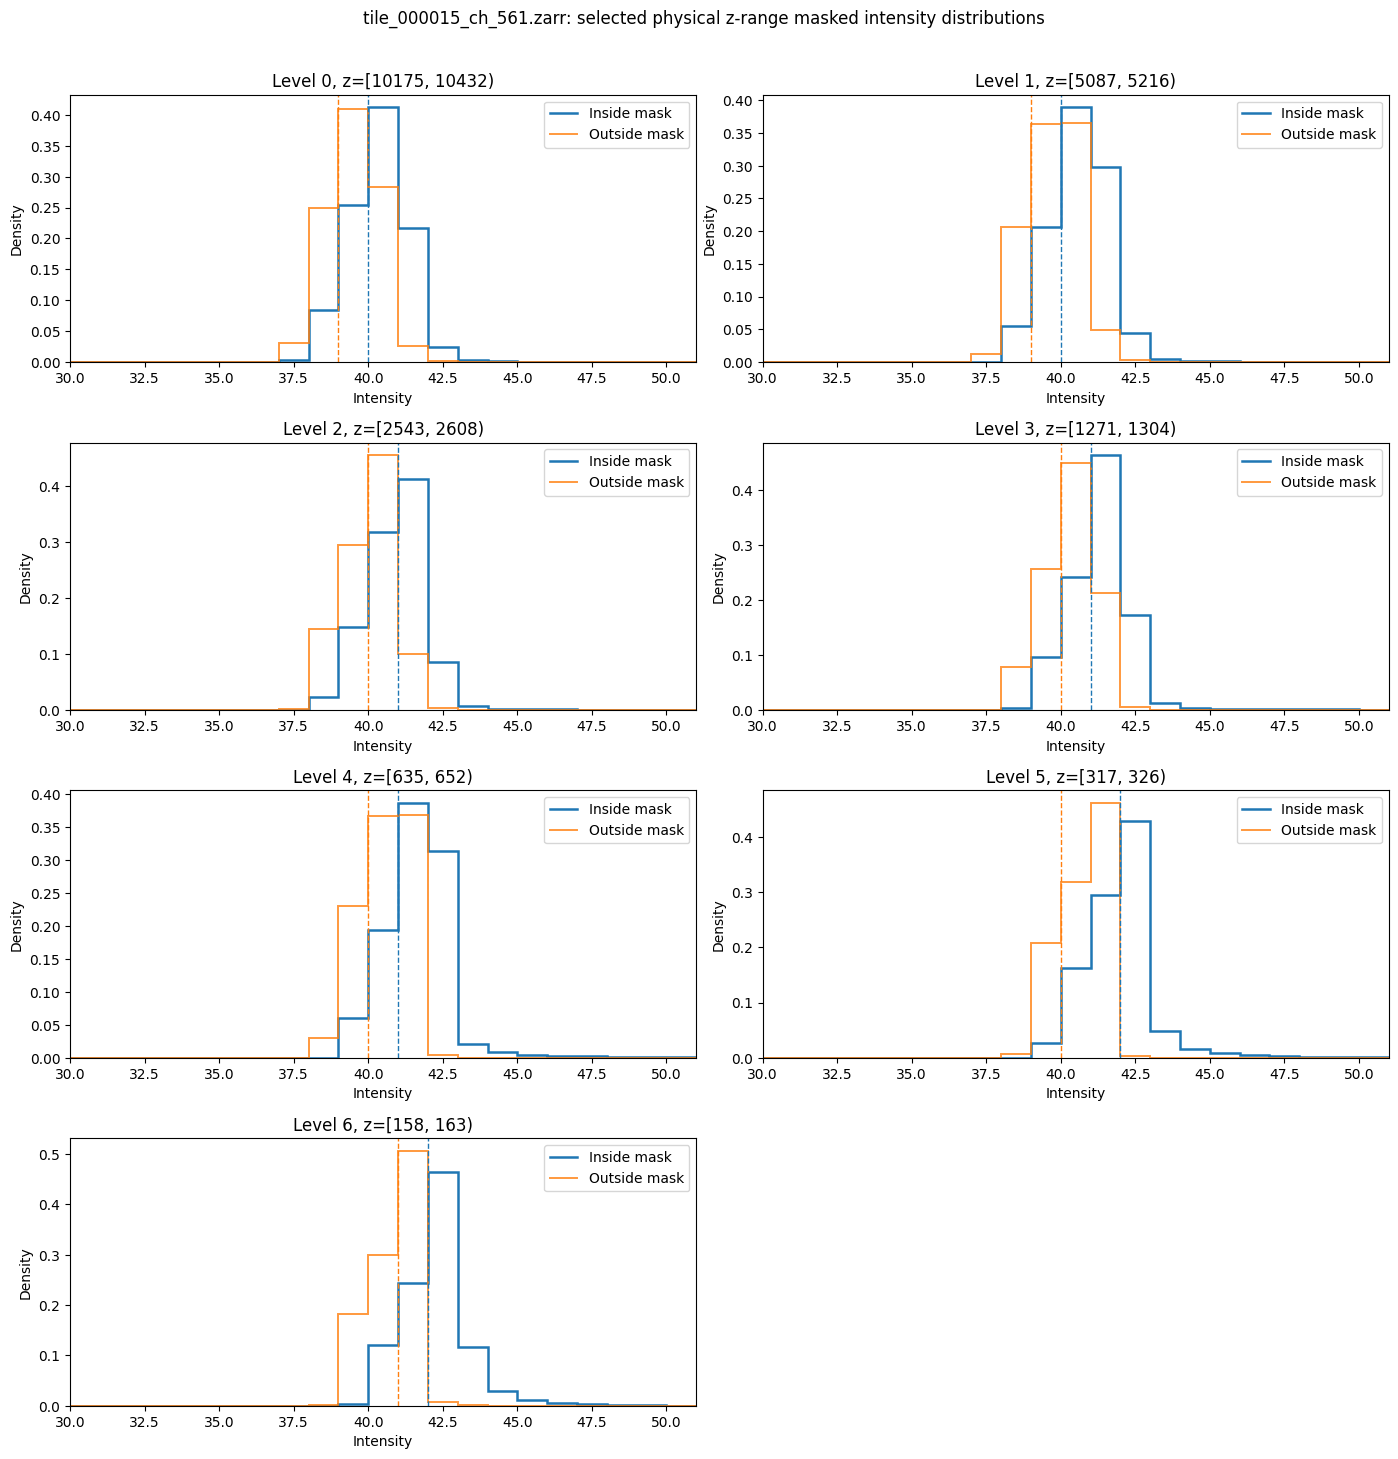

In [23]:
def intensity_bin_edges(
    counts: np.ndarray,
    low_max: int = LOW_INTENSITY_MAX,
    low_bin_width: int = LOW_INTENSITY_BIN_WIDTH,
    tail_bins: int = TAIL_DISPLAY_BINS,
) -> np.ndarray:
    """Build fine low-intensity bins plus coarse tail bins."""
    if low_bin_width < 1:
        raise ValueError("low_bin_width must be at least 1")

    nonzero = np.flatnonzero(counts)
    max_observed = int(nonzero[-1]) if nonzero.size else int(low_max)
    low_stop = min(int(low_max) + 1, counts.size)
    fine_edges = np.arange(0, low_stop + 1, low_bin_width, dtype=np.int64)
    if fine_edges[-1] != low_stop:
        fine_edges = np.append(fine_edges, low_stop)

    tail_stop = min(max_observed + 1, counts.size)
    if tail_stop <= low_stop:
        return fine_edges.astype(np.float64)

    tail_edges = np.unique(
        np.linspace(low_stop, tail_stop, tail_bins + 1, dtype=np.int64)
    )
    return np.unique(np.concatenate([fine_edges, tail_edges])).astype(np.float64)


def density_for_edges(counts: np.ndarray, edges: np.ndarray) -> np.ndarray:
    """Convert exact integer counts to density values for chosen bin edges."""
    edges_int = edges.astype(np.int64)
    values = np.array(
        [counts[edges_int[i] : edges_int[i + 1]].sum() for i in range(len(edges_int) - 1)],
        dtype=np.float64,
    )
    total = values.sum()
    widths = np.diff(edges)
    if total > 0:
        density = values / (total * widths)
    else:
        density = values
    return density


n_levels = len(analyzed_levels)
ncols = 2
nrows = math.ceil(n_levels / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.6 * nrows), squeeze=False)
axes_flat = axes.ravel()

for ax, level in zip(axes_flat, analyzed_levels):
    result = results_by_level[level]
    edges = intensity_bin_edges(result["inside_counts"] + result["outside_counts"])
    inside_density = density_for_edges(result["inside_counts"], edges)
    outside_density = density_for_edges(result["outside_counts"], edges)

    ax.stairs(inside_density, edges, label="Inside mask", linewidth=1.8)
    ax.stairs(outside_density, edges, label="Outside mask", linewidth=1.4, alpha=0.8)
    ax.axvline(result["inside_median_intensity"], color="C0", linestyle="--", linewidth=1)
    ax.axvline(result["outside_median_intensity"], color="C1", linestyle="--", linewidth=1)
    ax.set_title(f"Level {level}, z=[{result['z_start']}, {result['z_stop']})")
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Density")
    ax.set_xlim(30, PLOT_X_MAX)
    ax.legend()

for ax in axes_flat[n_levels:]:
    ax.axis("off")

fig.suptitle(f"{TILE_NAME}: selected physical z-range masked intensity distributions", y=1.01)
fig.tight_layout()
plt.show()


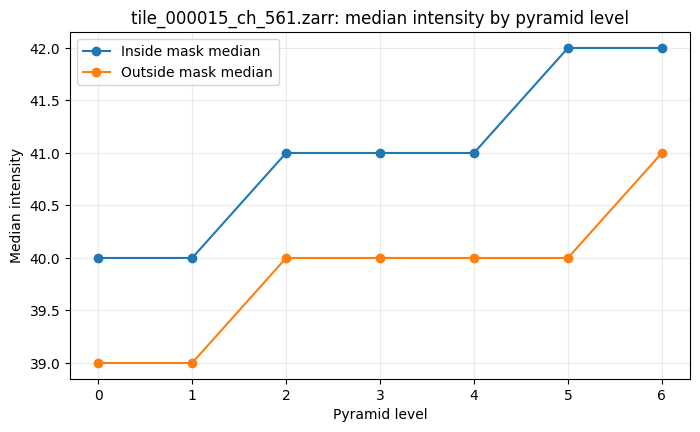

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.5))
levels_numeric = summary_df["level"].astype(int)

ax.plot(
    levels_numeric,
    summary_df["inside_median_intensity"],
    marker="o",
    label="Inside mask median",
)
ax.plot(
    levels_numeric,
    summary_df["outside_median_intensity"],
    marker="o",
    label="Outside mask median",
)
ax.set_xlabel("Pyramid level")
ax.set_ylabel("Median intensity")
ax.set_title(f"{TILE_NAME}: median intensity by pyramid level")
ax.set_xticks(levels_numeric)
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()
